In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/ptbxl_metadata_prepared.csv", index_col="ecg_id")
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

with h5py.File("../data/processed/raw_signals_100hz.h5", "r") as h5f:  # Lazy Loading
    patient_idx = 0
    single_signal = h5f["signals"][patient_idx]
    single_labels = h5f["labels"][patient_idx]
    patient_ecg_id = h5f["ecg_id"][patient_idx]

print(f"Wybrane badanie ID: {patient_ecg_id}")
print(f"Kształt sygnału (próbki x odprowadzenia): {single_signal.shape}")
print(f"Wektor etykiet (NORM, MI, STTC, CD, HYP): {single_labels}")

Wybrane badanie ID: 1
Kształt sygnału (próbki x odprowadzenia): (1000, 12)
Wektor etykiet (NORM, MI, STTC, CD, HYP): [1 0 0 0 0]


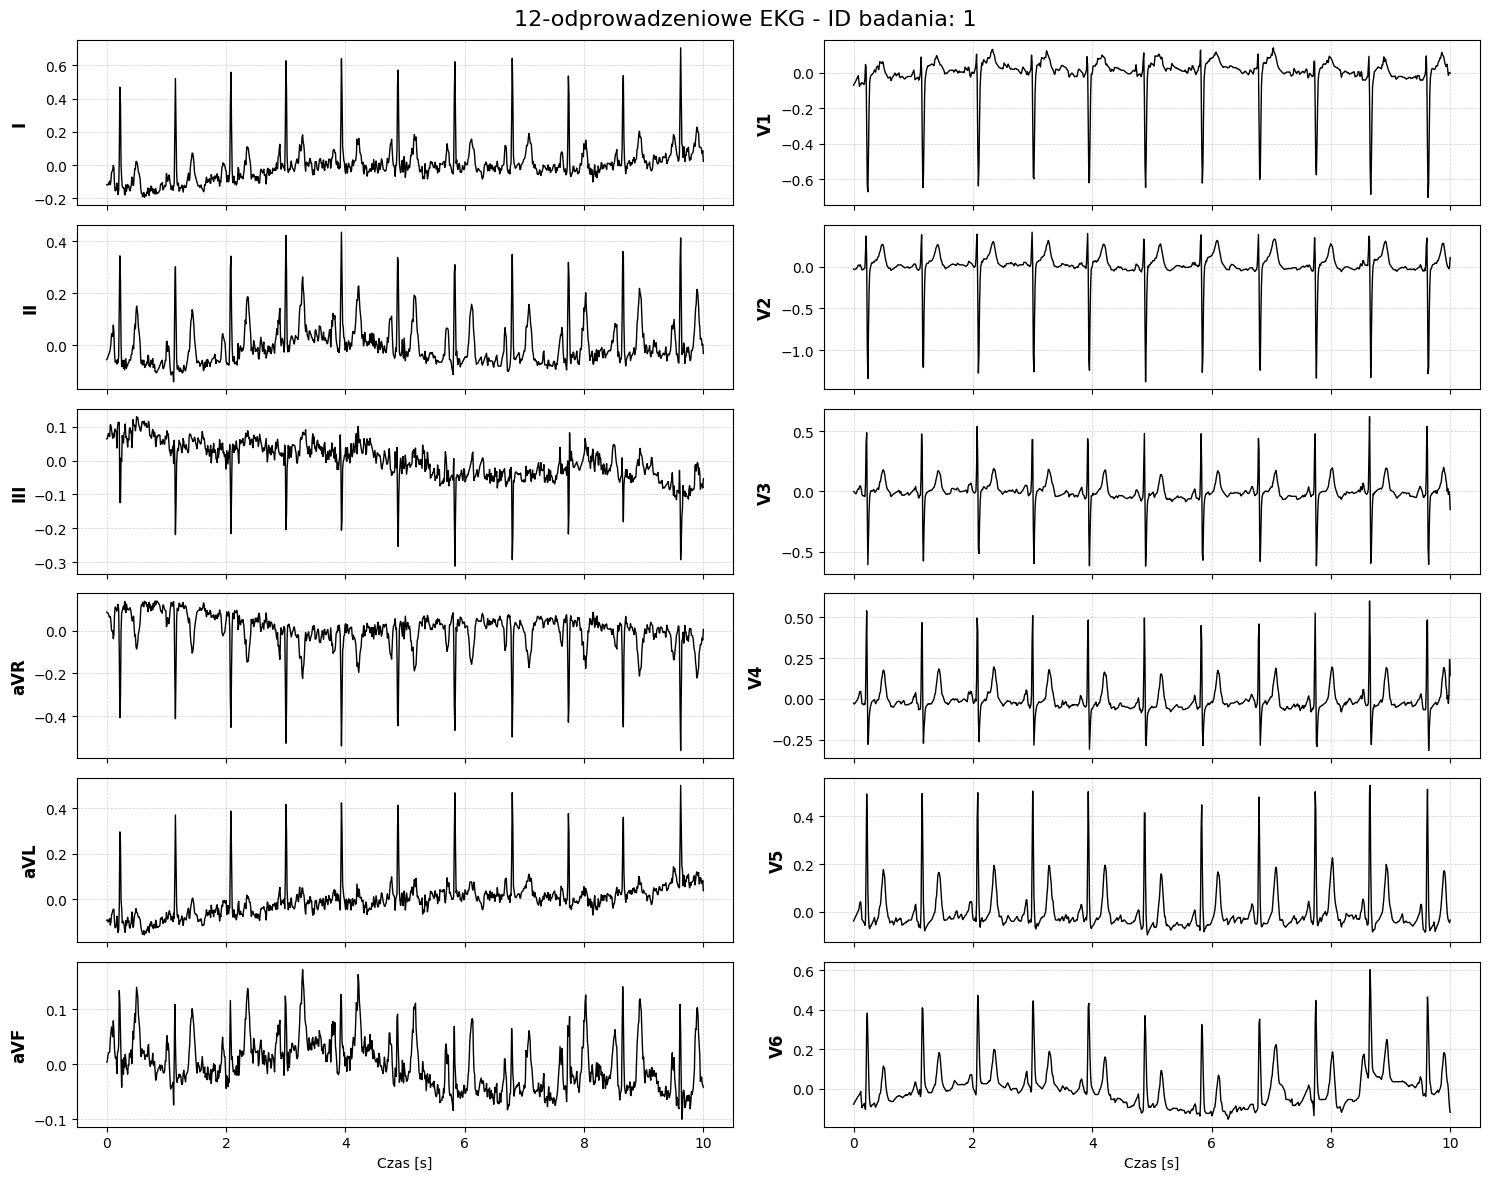

In [3]:
time_axis = np.linspace(0, 10, 1000)

fig, axes = plt.subplots(6, 2, figsize=(15, 12), sharex=True)
fig.suptitle(f"12-odprowadzeniowe EKG - ID badania: {patient_ecg_id}", fontsize=16)

for i in range(12):
    row = i % 6
    col = i // 6
    ax = axes[row, col]

    ax.plot(time_axis, single_signal[:, i], color='black', linewidth=1)
    ax.set_ylabel(lead_names[i], fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)

    if row == 5:
        ax.set_xlabel("Czas [s]")

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import wfdb

print("Metadane (ptbxl_metadata_cleaned.csv)")
df_clean = pd.read_csv('../data/processed/ptbxl_metadata_cleaned.csv', index_col='ecg_id')
print(f"Kształt tabeli (wiersze x kolumny): {df_clean.shape}")

Metadane (ptbxl_metadata_cleaned.csv)
Kształt tabeli (wiersze x kolumny): (21799, 27)


In [7]:
print("Typy danych w głównych kolumnach:")
print(df_clean[['age', 'weight', 'height', 'strat_fold', 'sex', 'filename_lr', 'report']].dtypes)

Typy danych w głównych kolumnach:
age            float64
weight         float64
height         float64
strat_fold       int64
sex              int64
filename_lr        str
report             str
dtype: object


In [4]:
print("Statystyki wieku pacjentów:")
print(df_clean['age'].describe())

Statystyki wieku pacjentów:
count    21506.000000
mean        59.537245
std         16.758773
min          2.000000
25%         50.000000
50%         61.000000
75%         72.000000
max         89.000000
Name: age, dtype: float64


In [6]:
print("Sygnały EKG (szeregi czasowe WFDB)")
record_path = '../data/raw/' + df_clean.iloc[0]['filename_lr']
signal, meta = wfdb.rdsamp(record_path)

print(f"Kształt macierzy EKG: {signal.shape} (próbki x odprowadzenia)")
print(f"Typ numeryczny: {signal.dtype}")

Sygnały EKG (szeregi czasowe WFDB)
Kształt macierzy EKG: (1000, 12) (próbki x odprowadzenia)
Typ numeryczny: float64


In [9]:
print("Rozkład kodów płci:")
print(df_clean['sex'].value_counts(dropna=False) / 21799.0)

Rozkład kodów płci:
sex
0    0.52085
1    0.47915
Name: count, dtype: float64


In [10]:
from src.split_data import split_and_save_metadata

split_and_save_metadata('../data/processed/ptbxl_metadata_cleaned.csv')

Podsumowanie podziału danych
Zbiór treningowy (folds 1-8): 17418 badań (79.9%)
Zbiór walidacyjny (fold 9):   2183 badań (10.0%)
Zbiór testowy (fold 10):      2198 badań (10.1%)

Pliki zapisane w data/processed/.


In [4]:
import pandas as pd
from scipy.stats import skew, kurtosis

df = pd.read_csv('../data/processed/train_meta.csv', index_col='ecg_id', low_memory=False)

def profile_dataset(df):
    profiling = []

    df['site'] = df['site'].astype(str)

    for col in df.columns:
        dtype = str(df[col].dtype)
        missing_pct = (df[col].isna().sum() / len(df)) * 100     # Odsetek brakujących wartości

        unique_vals = df[col].nunique()                          # Kategoryzacja własna
        if dtype in ['float64', 'int64'] and unique_vals > 20:
            var_type = 'Liczbowa ciągła/dyskretna'
        elif unique_vals <= 20:
            var_type = 'Kategorialna (binarna/wieloklasowa)'
        else:
            var_type = 'Tekstowa / Unikalna'

        # Szacowanie rozkładu i szumu (tylko dla cech liczbowych ciągłych)
        dist_type = '-'
        outliers_pct = '-'
        if var_type == 'Liczbowa ciągła/dyskretna' and df[col].notna().sum() > 0:
            clean_series = df[col].dropna()

            # Elementy odstające (Metoda rozstępu międzykwartylowego)
            Q1 = clean_series.quantile(0.25)
            Q3 = clean_series.quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((clean_series < (Q1 - 1.5 * IQR)) | (clean_series > (Q3 + 1.5 * IQR))).sum()
            outliers_pct = (outliers / len(clean_series)) * 100

            # Analiza skośności
            s = skew(clean_series)
            if abs(s) < 0.5:
                dist_type = 'Zbliżony do rozkładu normalnego'
            elif s >= 0.5:
                dist_type = 'Rozkład prawostronnie skośny'
            else:
                dist_type = 'Rozkład lewostronnie skośny'

        profiling.append({
            'Atrybut': col,
            'Typ danych': var_type,
            'Brakujące dane (%)': round(missing_pct, 2),
            'Obserwacje odstające (%)': round(outliers_pct, 2) if outliers_pct != '-' else '-',
            'Rodzaj rozkładu': dist_type
        })

    return pd.DataFrame(profiling)

if __name__ == '__main__':
    report = profile_dataset(df[['age', 'sex', 'height', 'weight', 'NORM', 'MI', 'STTC', 'CD', 'HYP', 'nurse', 'device', 'site']])
    display(report)

,Atrybut,Typ danych,Brakujące dane (%),Obserwacje odstające (%),Rodzaj rozkładu
0,age,Liczbowa ciągła/dyskretna,1.25,0.48,Rozkład lewostronnie skośny
1,sex,Kategorialna (binarna/wieloklasowa),0.00,-,-
2,height,Liczbowa ciągła/dyskretna,68.09,0.47,Rozkład lewostronnie skośny
3,weight,Liczbowa ciągła/dyskretna,58.45,1.3,Rozkład prawostronnie skośny
4,NORM,Kategorialna (binarna/wieloklasowa),0.00,-,-
5,MI,Kategorialna (binarna/wieloklasowa),0.00,-,-
6,STTC,Kategorialna (binarna/wieloklasowa),0.00,-,-
7,CD,Kategorialna (binarna/wieloklasowa),0.00,-,-
8,HYP,Kategorialna (binarna/wieloklasowa),0.00,-,-
9,nurse,Kategorialna (binarna/wieloklasowa),5.93,-,-


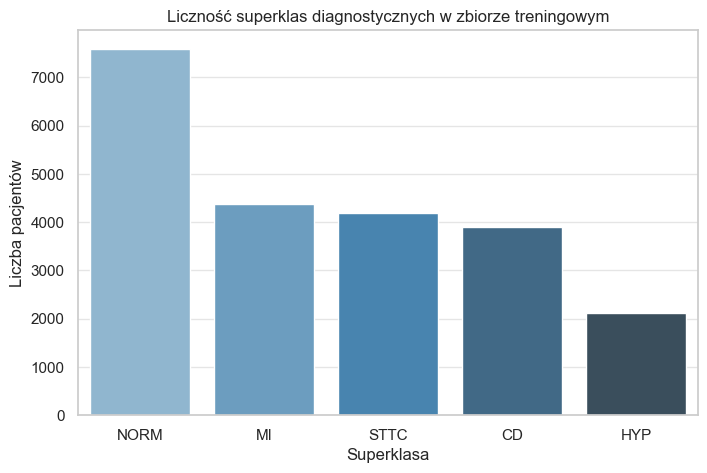

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/train_meta.csv', index_col='ecg_id', low_memory=False)
sns.set_theme(style="whitegrid")

# Rozkład superklas diagnostycznych
classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
class_counts = df[classes].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Blues_d", hue=class_counts.index, legend=False)
plt.title('Liczność superklas diagnostycznych w zbiorze treningowym')
plt.ylabel('Liczba pacjentów')
plt.xlabel('Superklasa')
plt.show()

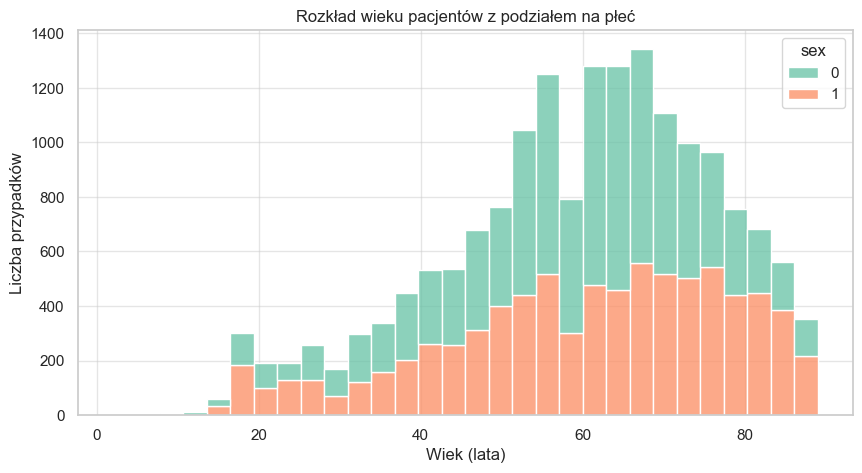

In [11]:
# Rozkład wieku z podziałem na płeć
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='age', hue='sex', multiple="stack", bins=30, palette="Set2")
plt.title('Rozkład wieku pacjentów z podziałem na płeć')
plt.xlabel('Wiek (lata)')
plt.ylabel('Liczba przypadków')
plt.show()

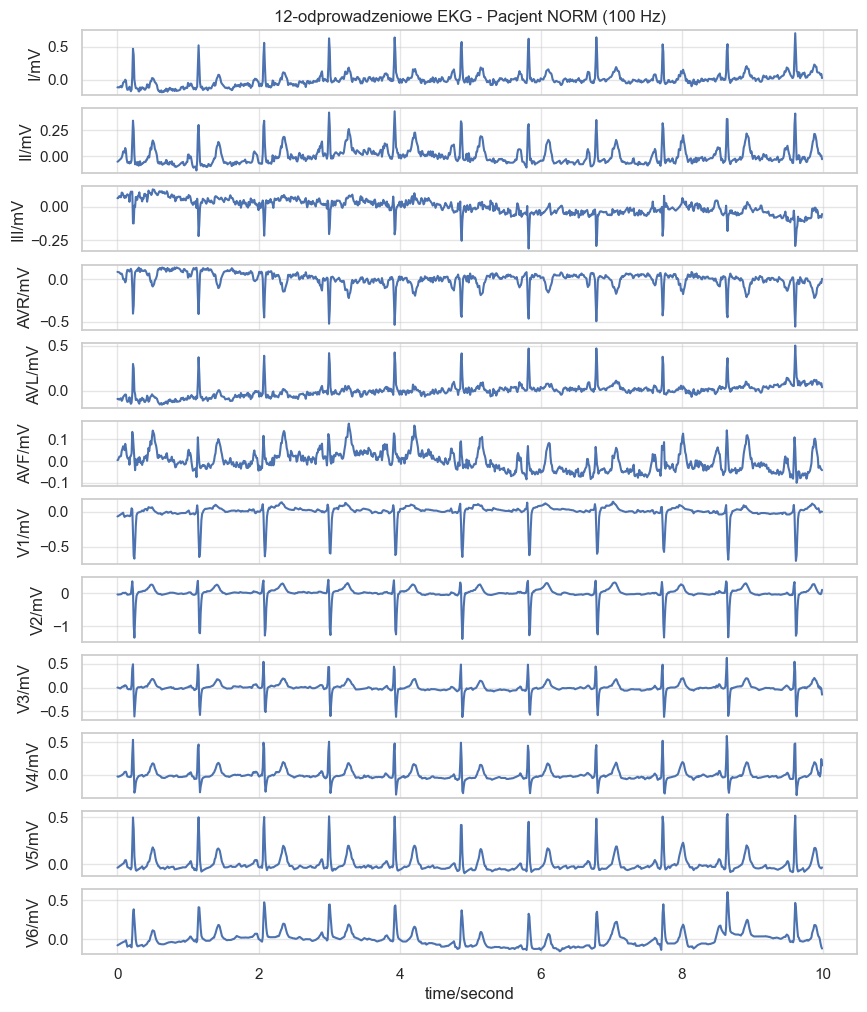

In [18]:
import wfdb

idx_norm = df[df['NORM'] == 1].iloc[0]['filename_lr']
idx_mi = df[df['MI'] == 1].iloc[0]['filename_lr']

# Pełne 12-odprowadzeniowe EKG (standard kliniczny)
record_norm = wfdb.rdrecord('../data/raw/' + idx_norm)
wfdb.plot_wfdb(record=record_norm, title='12-odprowadzeniowe EKG - Pacjent NORM (100 Hz)', figsize=(10, 12))

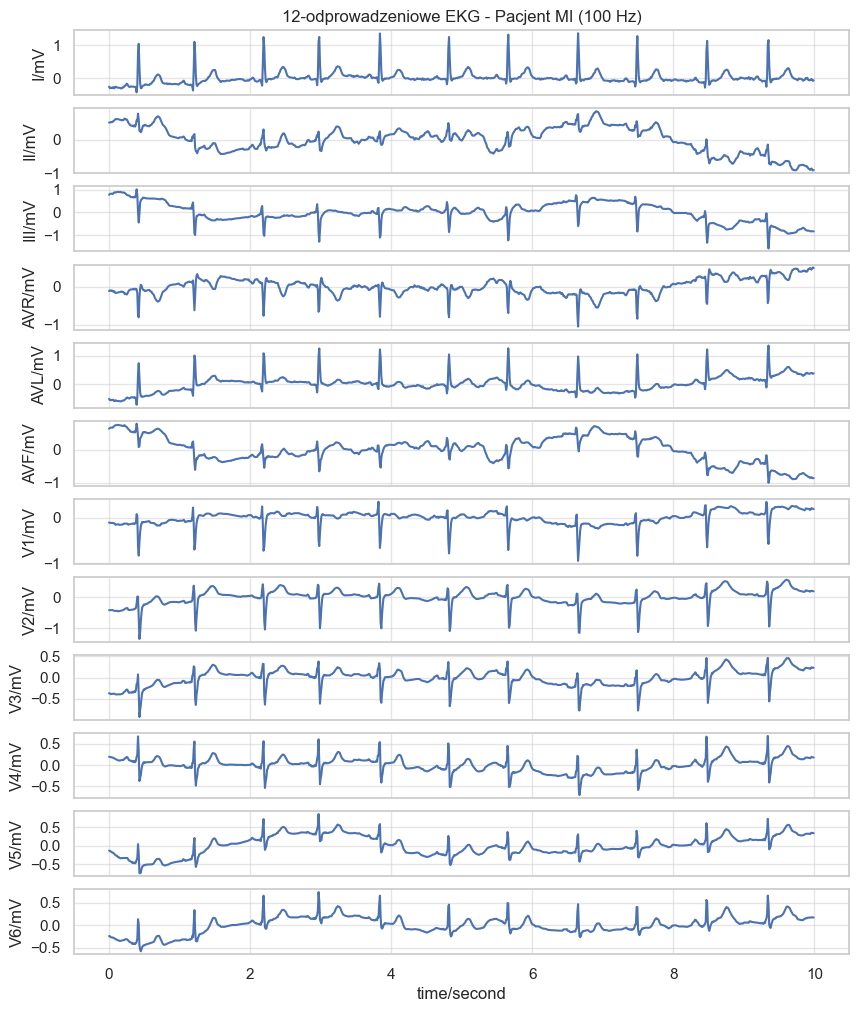

In [20]:
record_mi = wfdb.rdrecord('../data/raw/' + idx_mi)
wfdb.plot_wfdb(record=record_mi, title='12-odprowadzeniowe EKG - Pacjent MI (100 Hz)', figsize=(10, 12))

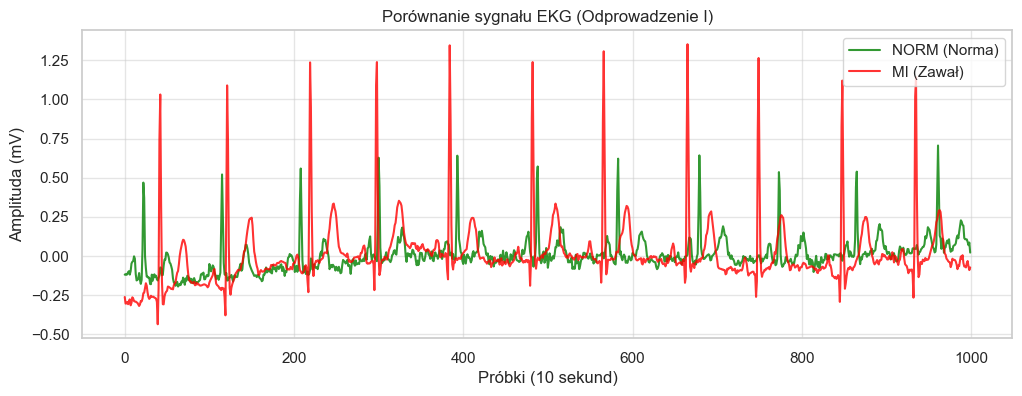

In [22]:
# Porównanie jednego odprowadzenia (np. Lead I)
signal_norm, _ = wfdb.rdsamp('../data/raw/' + idx_norm)
signal_mi, _ = wfdb.rdsamp('../data/raw/' + idx_mi)

plt.figure(figsize=(12, 4))
# Odprowadzenie I to indeks 0 w macierzy (1000, 12)
plt.plot(signal_norm[:, 0], label='NORM (Norma)', color='green', alpha=0.8)
plt.plot(signal_mi[:, 0], label='MI (Zawał)', color='red', alpha=0.8)
plt.title('Porównanie sygnału EKG (Odprowadzenie I)')
plt.xlabel('Próbki (10 sekund)')
plt.ylabel('Amplituda (mV)')
plt.legend()
plt.show()

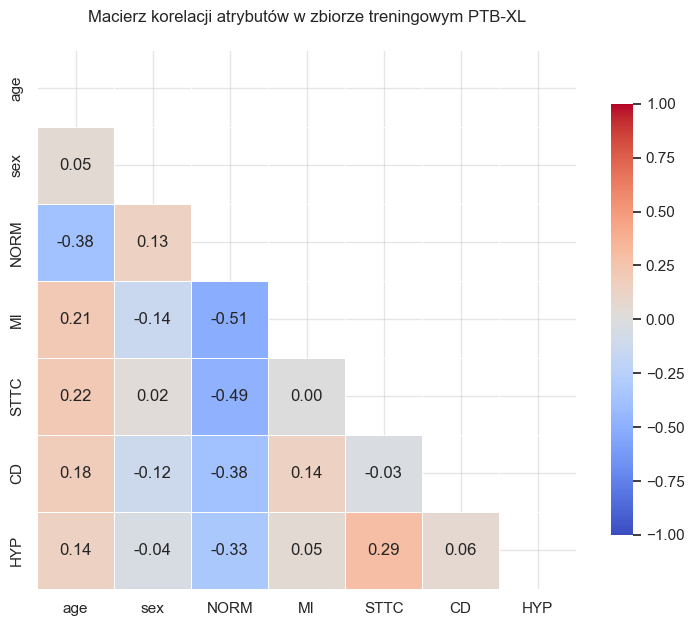

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../data/processed/train_meta.csv', index_col='ecg_id', low_memory=False)

# Wybierane są: wiek, płeć oraz 5 superklas diagnostycznych.
# Pomija się wzrost i wagę ze względu na ogromną liczbę braków danych.
cols_to_correlate = ['age', 'sex', 'NORM', 'MI', 'STTC', 'CD', 'HYP']
corr_df = df[cols_to_correlate].copy()
corr_matrix = corr_df.corr()
plt.figure(figsize=(9, 7))

# Wygenerowanie maski w celu ukrycia górnego trójkąta macierzy (unikanie dublowania informacji)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",     
    vmin=-1, vmax=1,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Macierz korelacji atrybutów w zbiorze treningowym PTB-XL', pad=20)
plt.show()